## Set-up
Import all necessary libraries

In [1]:
# import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os import listdir, chdir
from os.path import join
%matplotlib inline

In [2]:
# import image processing and pytoch
from PIL import Image
import torchvision.transforms as transforms
from torchvision import tv_tensors

import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn as nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

### Helper functions

In [3]:
def df_of_filepaths(images_path, masks_path):
    """
    Create dataframe of paths of images and their corresponding mask based on folders images_path and masks_path
    """

    images = [join(images_path, f).replace("\\","/") for f in listdir(images_path)]
    masks = [join(masks_path, f).replace("\\","/") for f in listdir(masks_path)]
    df = pd.DataFrame({"images": images, "masks": masks})

    return df

In [45]:
def plot_image_and_mask(image, mask, pred=None):
    if pred is None:
        fig, ax = plt.subplots(1,2)
    else:
        fig, ax = plt.subplots(1,3)
        ax[2].set_title("prediction")
        ax[2].imshow(np.asarray(pred), cmap="grey")
    ax[0].set_title("image")
    ax[0].imshow(np.asarray(image))
    ax[1].set_title("mask")
    ax[1].imshow(np.asarray(mask), cmap="grey")

    plt.show()


def plot_tensor_image_and_mask(tensor_image, tensor_mask, tensor_pred=None):

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # unprocess image
    image = tensor_image.numpy().transpose((1, 2, 0))
    image = std * image + mean # Undo preprocessing
    image = np.clip(image, 0, 1) # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    
    # unprocess mask 
    mask = tensor_mask.numpy().transpose((1, 2, 0))
    #mask = std * mask + mean # Undo preprocessing
    mask = np.clip(mask, 0, 1)
    #image = np.clip(image, 0, 1) # Image needs to be clipped between 0 and 1 or it looks like noise when displayed

    if tensor_pred is None:
        plot_image_and_mask(image, mask)
    else:
        # unprocess pred
        pred = tensor_pred.numpy().transpose((1, 2, 0))
        pred = np.clip(pred, 0, 1)

        plot_image_and_mask(image, mask, pred)



## Configuration

In [5]:
train_images_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\1. Original Images\a. Training Set"
test_images_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\1. Original Images\b. Testing Set"
train_masks_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\2. All Segmentation Groundtruths\a. Training Set\1. Microaneurysms"
test_masks_path = r"C:\Users\Michelle\deepLearning\pytorch_retinopathy\A. Segmentation\2. All Segmentation Groundtruths\b. Testing Set\1. Microaneurysms"

# create dataframe of paths to files of train and test set
train_df = df_of_filepaths(train_images_path, train_masks_path)
test_df = df_of_filepaths(test_images_path, test_masks_path)

test_df.head()

,images,masks
0,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
1,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
2,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
3,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...
4,C:/Users/Michelle/deepLearning/pytorch_retinop...,C:/Users/Michelle/deepLearning/pytorch_retinop...


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_images_path = r"/content/drive/MyDrive/A. Segmentation/1. Original Images/a. Training Set"
test_images_path = r"/content/drive/MyDrive/A. Segmentation/1. Original Images/b. Testing Set"
train_masks_path = r"/content/drive/MyDrive/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms"
test_masks_path = r"/content/drive/MyDrive/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/1. Microaneurysms"

# create dataframe of paths to files of train and test set
train_df = df_of_filepaths(train_images_path, train_masks_path)
test_df = df_of_filepaths(test_images_path, test_masks_path)

test_df.head()

## Import and Explore Data

All images are named as "IDRiD_xx.jpg" and its corresponding mask is named as "IDRiD_xx_HE.tif" where xx is the id, from 01-81 (54 images are in the training set).

An image and its mask can be brought in and looked based on selecting a random id which exists in the training set. 

In [6]:
idx = 10

image_path = train_df.at[idx, "images"]
mask_path = train_df.at[idx, "masks"]

# with cv2
#image = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
#mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0

# with PIL
image = Image.open(image_path)
mask = Image.open(mask_path)

print(f"The shape of the image is {np.asarray(image).shape}.")
print(f"The shape of the mask is {np.asarray(mask).shape}.")

The shape of the image is (2848, 4288, 3).
The shape of the mask is (2848, 4288).


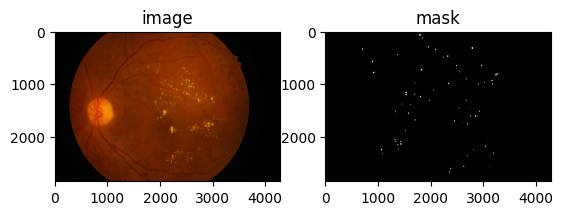

In [7]:
# plot image and its mask
plot_image_and_mask(image, mask)


Each training image is 2848 x 4288 x 3 channels (RGB), while its mask is 2848 x 4288. 

## Preprocessing
The data is preprocessed, and prepared for using as input and test data.

### Augmentation
Augmentions such as random horizontal flips and random rotations are applied to the (training) images and masks. All images and masks are resized, converted to tensors, and normalized. 

These augmentations are first explored on one image-mask set, and then applied to the entire training and testing set via a custom class. 

In [8]:
IMG_SIZE = 224

train_transform = v2.Compose([
    v2.Resize(size=(IMG_SIZE, IMG_SIZE), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=0.15),
    v2.ColorJitter(contrast=0.2, brightness=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.Resize(size=(IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

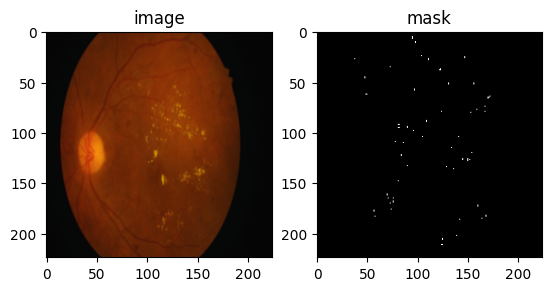

In [9]:
# transform an image and its mask to see the effects of the transforms
image_transform, mask_transform = train_transform(tv_tensors.Image(image), tv_tensors.Mask(mask))

# plot transformed image and its mask
plot_tensor_image_and_mask(image_transform, mask_transform)

In [10]:
class SegmentationDataset(Dataset):

    def __init__(self, df, transforms):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # get path to image and mask
        image_path = self.df.at[idx, "images"]
        mask_path = self.df.at[idx, "masks"]

        # open image and path in right mode
        image = Image.open(image_path) # h, w, c
        if image.mode != "RGB":
            image = image.convert("RGB")
        
        mask = Image.open(mask_path) # h, w
        if mask.mode != "L":
            mask = mask.convert("L")

        # apply transforms
        if self.transforms:
            image_transform, mask_transform =  self.transforms(tv_tensors.Image(image), tv_tensors.Mask(mask))

        return image_transform, mask_transform

In [11]:
# create training and testing set with transformations
trainset = SegmentationDataset(train_df, train_transform)
testset = SegmentationDataset(test_df, test_transform)

print(f"The training set has {len(trainset)} observations.")
print(f"The test set has {len(testset)} observations.")

The training set has 54 observations.
The test set has 27 observations.


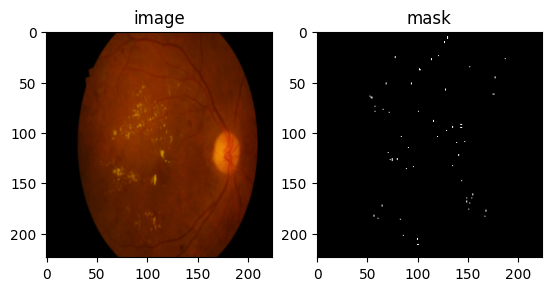

In [12]:
idx = 10
imageX, maskX = trainset[idx]
plot_tensor_image_and_mask(imageX, maskX)

### Load into batches
The datasets are loaded into batches for efficient computation. Since the dataset is relatively small, a batch size of 4 is used so that batches are approximately the same length. 

In [13]:
BATCH_SIZE = 16

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE)

print(f"There are {len(trainloader)} batches in the trainloader.")
print(f"There are {len(testloader)} batches in the testloader.")

There are 4 batches in the trainloader.
There are 2 batches in the testloader.


In [14]:
# verify correct size
for imageX, maskX in trainloader:
    break

print(f"One batch image shape: {imageX.shape}")
print(f"One batch mask shape: {maskX.shape}")

One batch image shape: torch.Size([16, 3, 224, 224])
One batch mask shape: torch.Size([16, 1, 224, 224])


## Create Segmentation Model
Create a segmentation model based on the pre-trained UNet architecture (which has been shown to be appropriate for medical images) and DiceLoss. 

Tuning will be explored for the following hyperparameters:
* encoders (trade-off between computational efficiency and capability to capture complexity of segmention) : use `["resnet34", "efficientnet-b0", "timm-efficientnet-b0"]`

In the future, hyperparameters like momentum, and number of epochs can also be explored. 

In [15]:
# configuration
encoders = ["resnet34", "efficientnet-b0", "mobileone_s0"]
ENCODER_WEIGHTS = "imagenet"
lrs = [0.001, 0.0001]
EPOCHS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {DEVICE}.")


Device is cpu.


In [16]:
# define custom segmentation model class
class SegmentationModel(nn.Module):
    def __init__(self, encoder, weights):
        super(SegmentationModel, self).__init__()

        self.arc = smp.Unet(
            encoder_name=encoder, 
            encoder_weights=weights, 
            in_channels=3, 
            classes=1, 
            activation=None
        )

    def forward(self, images, masks=None):

        logits = self.arc(images)

        if masks != None:
            loss1 = DiceLoss(mode="binary")(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks.float())
            return logits, loss1 + loss2
        
        return logits

In [17]:
# define training and validation function for the model
def train_seg_model(data_loader, model, optimizer):

    model.train()
    total_loss = 0.0

    for images, masks in tqdm(data_loader):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()               # set gradients to 0
        logits, loss = model(images, masks)  # forward pass
        loss.backward()                     # backward pass
        optimizer.step()                    # update weights and biases

        total_loss += loss.item()
    
    return total_loss / len(data_loader)

def test_seg_model(data_loader, model):

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(data_loader):
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            logits, loss = model(images, masks) 

            total_loss += loss.item()
    
    return total_loss / len(data_loader)

In [18]:
"""
model = SegmentationModel(encoder="timm-efficientnet-b0", weights="imagenet")
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_valid_loss = np.inf
corresponding_train_loss = None

# TRAINING LOOP
epochs = 5
for i in range(epochs):
    train_loss = train_seg_model(data_loader=trainloader, model=model, optimizer=optimizer)
    valid_loss = test_seg_model(data_loader=testloader, model=model)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        corresponding_train_loss = train_loss

    print(f"    Epoch {i+1}/{epochs}: train_loss {train_loss:.4f} // valid_loss {valid_loss:.4f}")
"""

'\nmodel = SegmentationModel(encoder="timm-efficientnet-b0", weights="imagenet")\nmodel.to(DEVICE)\n\noptimizer = torch.optim.Adam(model.parameters(), lr=0.001)\n\nbest_valid_loss = np.inf\ncorresponding_train_loss = None\n\n# TRAINING LOOP\nepochs = 5\nfor i in range(epochs):\n    train_loss = train_seg_model(data_loader=trainloader, model=model, optimizer=optimizer)\n    valid_loss = test_seg_model(data_loader=testloader, model=model)\n\n    if valid_loss < best_valid_loss:\n        best_valid_loss = valid_loss\n        corresponding_train_loss = train_loss\n\n    print(f"    Epoch {i+1}/{epochs}: train_loss {train_loss:.4f} // valid_loss {valid_loss:.4f}")\n'

In [19]:
all_results = [] # save losses over all hyperparameter tuning
all_results_losses = {}

overall_best_valid_loss = np.inf
overall_corresponding_train_loss = None

for encoder in encoders:

    for lr in lrs:

        model = SegmentationModel(encoder=encoder, weights=ENCODER_WEIGHTS)
        model.to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        print(f">>> STARTING TRAINING LOOP FOR encoder={encoder}, lr={lr}")

        # track the best validation loss over the given number of epochs
        best_valid_loss = np.inf
        corresponding_train_loss = None

        all_train_loss = []
        all_valid_loss = []

        # TRAINING LOOP
        for i in range(EPOCHS):
            train_loss = train_seg_model(data_loader=trainloader, model=model, optimizer=optimizer)
            valid_loss = test_seg_model(data_loader=testloader, model=model)

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                corresponding_train_loss = train_loss

            all_train_loss.append(train_loss)
            all_valid_loss.append(valid_loss)
            print(f"    Epoch {i+1}/{EPOCHS}: train_loss {train_loss:.4f} // valid_loss {valid_loss:.4f}")
                
        # save results for all hyperparameter
        all_results.append([encoder, lr, best_valid_loss, corresponding_train_loss])
        all_results_losses[f"{encoder}_{lr}"] = {"train_loss": all_train_loss, "valid_loss": all_valid_loss}

        # check if best global model; if so, save it! 
        if best_valid_loss < overall_best_valid_loss:
            torch.save(model.state_dict(), "best_model.pt")
            print("saved model")
            overall_best_valid_loss = best_valid_loss
            overall_corresponding_train_loss = corresponding_train_loss


>>> STARTING TRAINING LOOP FOR encoder=resnet34, lr=0.001


100%|██████████| 2/2 [00:09<00:00,  4.58s/it]


    Epoch 1/20: train_loss 1.5253 // valid_loss 1.3901


100%|██████████| 2/2 [00:13<00:00,  6.85s/it]


    Epoch 2/20: train_loss 1.3997 // valid_loss 1.8504


...

    Epoch 18/20: train_loss 1.3873 // valid_loss 1.4188


100%|██████████| 2/2 [00:10<00:00,  5.09s/it]


    Epoch 19/20: train_loss 1.3806 // valid_loss 1.4124


100%|██████████| 2/2 [00:10<00:00,  5.39s/it]

    Epoch 20/20: train_loss 1.3672 // valid_loss 1.4056


Max logit: 6.365752220153809
Min logit: -2.790651559829712
Max prob: 0.9982835054397583


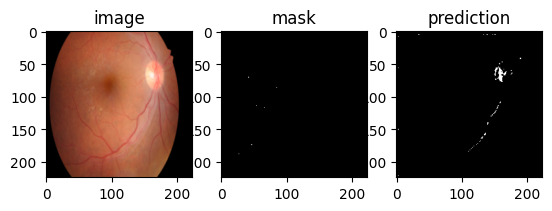

In [55]:
idx = 2
image, mask = testset[idx]

model.eval()
with torch.no_grad():
    logits_mask = model(image.to(DEVICE).unsqueeze(0))

print(f"Max logit: {logits_mask.max().item()}")
print(f"Min logit: {logits_mask.min().item()}")
print(f"Max prob: {torch.sigmoid(logits_mask).max().item()}")

pred_mask = torch.sigmoid(logits_mask) > 0.995
pred_mask = pred_mask.detach().cpu().squeeze(0)

plot_tensor_image_and_mask(image, mask, pred_mask)